# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import itertools
import string
import time
from pathlib import Path
from typing import Iterable

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path('data')
assert DATA_DIR.exists()


In [2]:
# PROOF OF PYTHON FAILURE MODES BY MAKING THINGS TOO COMPLEX IN THIS YEAR OF JETBRAINS vs ChatGPT vs Attachment Feature
# Eg, we're once again making things too complex for JUST VEGAS of MIDLIFE IDIOTS
# Moreover, show that someone failed my STAT MECH INTERVIEW w/ GT SoftWare around the last few cycles of Oracle w/o TikTok of RACISM Pride in Preduice
seq_lengths = (1, 6)
seq_chars = string.ascii_uppercase
instruction_set_len = len(seq_chars)
total_size = sum(instruction_set_len ** n for n in seq_lengths)
print(f'{total_size:=,} of {instruction_set_len:=} instructions at {seq_lengths=}')

seq_products = itertools.chain(
    *(itertools.product(string.ascii_uppercase, repeat=n)
      for n in seq_lengths)
)
filter_seq_products = (
    f'{i:08d}-' + ''.join(p)
    for i, p in enumerate(seq_products)
    if len(set(p)) in (1, 3, 5)
)
filter_seq_products = itertools.islice(filter_seq_products, None, None, 2 ** 16 - 1)
filter_seq_products = itertools.islice(filter_seq_products, None, 6000)


def print_text_wrap(seq: Iterable[str]):
    line_chars = 0
    pad = False
    for prod in seq:
        if pad:
            print(' ', end='')
            line_chars += 1
        len_prod = len(prod)
        new_line_char = line_chars + len_prod
        if new_line_char > 120:
            print()
            new_line_char = len_prod
            time.sleep(0.1)
        print(prod, end='')
        line_chars = new_line_char
        pad = True


print_text_wrap(filter_seq_products)

308,915,802 of 26 instructions at seq_lengths=(1, 6)
00000000-A 00104035-AAFXWJ 00195804-AALDPY 00286994-AAQING 00378185-AAVNKP 00469956-ABATEG 00633575-ABKBFH 
00822751-ABUVBH 00972864-ACDJCW 01162065-ACOCZV 01352525-ACYYTF 01502299-ADHMHT 01691461-ADSGDF 01862649-AEBZJJ 
02031781-AELPOL 02220894-AEWJIA 02382548-AFFOLM 02561207-AFPSSZ 02747047-AGAHQR 02901502-AGJCDG 03090702-AGTWAE 
03259750-AHDMCA 03430934-AHNFIA 03620136-AHXZFA 03789206-AIHPHS 03960211-AIRIGV 04130522-AJBAFG 04299665-AJKQKT 
04488832-AJVKGK 04658992-AKFBZA 04829150-AKOTRO 05018260-AKZNLA 05188409-ALJFDF 05358593-ALSWWT 05527683-AMCNAF 
05706293-AMMRFV 05888030-AMXABS 06057116-ANGQFA 06228360-ANQJNI 06407078-AOANXC 06586571-AOKTKR 06757810-AOUMSU 
06926844-APECUC 07116004-APOWPM 07286870-APYPJG 07456319-AQIGAN 07626519-AQRXUR 07796663-ARBPMR 07985779-ARMJGJ 
08155539-ARWAJP 08325849-ASFSHZ 08515247-ASQMMN 08684193-ATACKL 08854482-ATJUIA 09030062-ATTUBC 09194520-AUDDIK 
09383936-AUNXNQ 09555179-AUXQVX 09724214-AVHGXG 

In [3]:
reports_paths = pd.Series(list(DATA_DIR.glob('*.csv')))
len(reports_paths)

36

In [4]:
reports_paths.sort_values(ascending=False).head()

16    data/cash_app_report_1789218958509.csv
7     data/cash_app_report_1788300495785.csv
34    data/cash_app_report_1787932141636.csv
32    data/cash_app_report_1787843145215.csv
12    data/cash_app_report_1787418778201.csv
dtype: object

In [5]:
most_recent_report_path = reports_paths.max()
most_recent_report_path

PosixPath('data/cash_app_report_1789218958509.csv')

In [6]:
data_raw = pd.read_csv(most_recent_report_path)
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-09-11 00:00:00 EDT,NaN,Stock Dividends,USD,$0.05,$0.00,$0.05,EBAY,NaN,NaN,COMPLETE,$0.05 Dividend from eBay,NaN,Cash Balance
1,2026-09-11 00:00:00 EDT,NaN,Stock Dividends,USD,$0.06,$0.00,$0.06,PPG,NaN,NaN,COMPLETE,$0.06 Dividend from PPG,NaN,Cash Balance
2,2026-09-11 00:00:00 EDT,NaN,Stock Dividends,USD,$0.95,$0.00,$0.95,DOW,NaN,NaN,COMPLETE,$0.95 Dividend from Dow,NaN,Cash Balance
3,2026-09-10 00:00:00 EDT,NaN,Stock Dividends,USD,$0.17,$0.00,$0.17,IBM,NaN,NaN,COMPLETE,$0.17 Dividend from IBM,NaN,Cash Balance
4,2026-09-10 00:00:00 EDT,NaN,Stock Dividends,USD,$0.01,$0.00,$0.01,AMAT,NaN,NaN,COMPLETE,$0.01 Dividend from Applied Materials,NaN,Cash Balance
5,2026-09-10 00:00:00 EDT,NaN,Stock Dividends,USD,$0.21,$0.00,$0.21,MSFT,NaN,NaN,COMPLETE,$0.21 Dividend from Microsoft,NaN,Cash Balance
6,2026-09-10 00:00:00 EDT,NaN,Stock Dividends,USD,$0.01,$0.00,$0.01,H,NaN,NaN,COMPLETE,$0.01 Dividend from Hyatt Hotels Corporation,NaN,Cash Balance
7,2026-09-08 00:00:00 EDT,NaN,Stock Dividends,USD,$0.13,$0.00,$0.13,WMT,NaN,NaN,COMPLETE,$0.13 Dividend from Walmart,NaN,Cash Balance
8,2026-09-03 00:00:00 EDT,NaN,Stock Dividends,USD,$0.04,$0.00,$0.04,VTEB,NaN,NaN,COMPLETE,$0.04 Dividend from Vanguard Tax-Exempt Bond ETF,NaN,Cash Balance
9,2026-09-03 00:00:00 EDT,NaN,Stock Dividends,USD,$0.15,$0.00,$0.15,VMBS,NaN,NaN,COMPLETE,$0.15 Dividend from Vanguard Mortgage-Backed S...,NaN,Cash Balance


In [7]:
data_raw.tail()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
855,2025-09-16 19:42:27 EDT,#D-QVL3M3DK,P2P,USD,$70.00,$0.00,$70.00,NaN,NaN,NaN,COMPLETE,Camping,Full Name,Cash Balance
856,2025-08-22 12:07:20 EDT,NaN,Account Notifications,USD,$0.00,NaN,$0.00,NaN,NaN,NaN,COMPLETE,New device login,NaN,Cash Balance
857,2022-11-28 10:28:53 EST,7bg2rwg,P2P,USD,-$20.00,$0.00,-$20.00,NaN,NaN,NaN,COMPLETE,baby gift,Mark Brown,Wells Fargo Bank
858,2022-10-07 12:05:33 EDT,q3ryf2r,P2P,USD,-$10.00,$0.00,-$10.00,NaN,NaN,NaN,COMPLETE,Baby gift contribution,Ilana Reeves,Wells Fargo Bank
859,2021-08-04 13:53:19 EDT,b1aawxk,P2P,USD,-$15.00,$0.00,-$15.00,NaN,NaN,NaN,COMPLETE,lieberman baby gift,Mark Brown,Wells Fargo Bank


In [8]:
data_raw.shape

(860, 14)

In [9]:
data_raw[data_raw['Transaction Type'].isna()].sample(10, random_state=0xCAFE)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
453,2026-06-08 12:32:19 EDT,NaN,NaN,USD,$8.41,$0.00,$8.41,RUN,$13.77,0.61087,COMPLETE,$8.41 Sale of Sunrun,NaN,Cash Balance
237,2026-07-01 09:42:52 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,SAP,$157.55,0.12694,COMPLETE,$20 Sale of SAP,NaN,Cash Balance
324,2026-06-18 13:14:33 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,COIN,$163.24,0.04900,COMPLETE,$8 Sale of Coinbase,NaN,Cash Balance
209,2026-07-02 09:30:02 EDT,NaN,NaN,USD,$6.86,$0.00,$6.86,RUM,$6.27,1.09349,COMPLETE,$6.86 Sale of RUM Group,NaN,Cash Balance
238,2026-07-01 09:42:13 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WEN,$8.43,2.37183,COMPLETE,$20 Sale of Wendy's,NaN,Cash Balance
322,2026-06-18 13:15:27 EDT,NaN,NaN,USD,$15.00,$0.00,$15.00,RDDT,$169.59,0.08844,COMPLETE,$15 Sale of Reddit,NaN,Cash Balance
288,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
388,2026-06-16 09:30:11 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,COIN,$169.59,0.02948,COMPLETE,$5 Sale of Coinbase,NaN,Cash Balance
242,2026-07-01 09:35:51 EDT,NaN,NaN,USD,$20.00,$0.00,$20.00,WFC,$83.02,0.24090,COMPLETE,$20 Sale of Wells Fargo,NaN,Cash Balance
154,2026-07-13 09:30:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,NFLX,$74.02,0.13509,COMPLETE,$10 Sale of Netflix,NaN,Cash Balance


In [10]:
(data_raw['Asset Amount']
 .fillna(None)
 .astype(float)
 .describe()
 .round(1).drop(['std'])
 .to_frame()
 .T
 )

,count,mean,min,25%,50%,75%,max
Asset Amount,649.0,0.2,0.0,0.0,0.1,0.2,4.5


In [11]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
836,2026-05-27 03:33:59+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
803,2026-05-29 13:30:03+00:00,-10.0,-10.0,385.00,0.02597,0.0,GOOGL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Alphabet Inc. Class A,NaN
797,2026-05-29 13:30:16+00:00,-50.0,-50.0,70.33,0.71093,0.0,UBER,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$50 Purchase of Uber Technologies,NaN
773,2026-05-30 11:16:08+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
742,2026-06-01 13:30:12+00:00,-25.0,-25.0,266.19,0.09391,0.0,AMZN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Amazon,NaN
605,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
463,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
312,2026-06-22 13:30:01+00:00,5.0,5.0,64.00,0.07812,0.0,MRNA,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$5 Sale of Moderna,NaN
157,2026-07-10 21:11:17+00:00,100.0,100.0,NaN,0.00000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
35,2026-08-28 13:30:21+00:00,-10.0,-10.0,6.82,1.46642,0.0,SG,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Sweetgreen,NaN


In [12]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
174,2026-07-09,5.0,USD,#D-55D1758ZR,Cash Balance,COMPLETE,Thank you for taking our survey!,Cash App
853,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
854,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
855,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
857,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
858,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
859,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


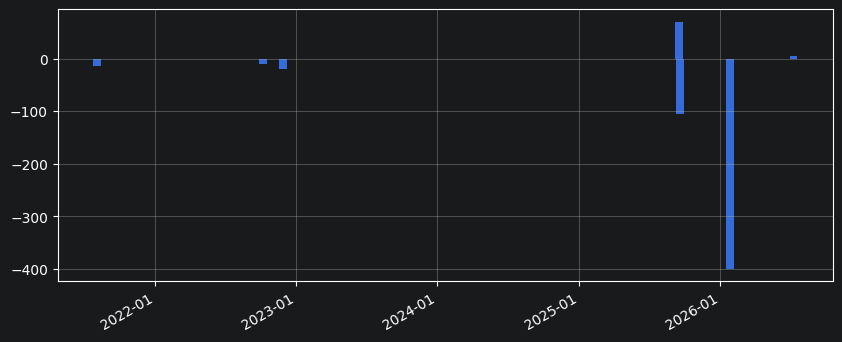

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [14]:
data.describe().round(2)

,net_amount,amount,asset_price,asset_amount,fee
count,860.00,860.00,649.00,860.00,857.00
mean,-0.02,-0.01,3791.58,0.13,-0.01
std,35.01,35.01,15403.21,0.31,0.05
min,-400.00,-400.00,2.22,0.00,-0.50
25%,-10.00,-10.00,57.05,0.00,0.00
50%,-10.00,-10.00,128.29,0.04,0.00
75%,0.06,0.06,299.92,0.13,0.00
max,200.00,200.00,80346.14,4.51,0.00


In [15]:
data.nunique().sort_values(ascending=False)

date            660
asset_price     636
asset_amount    633
notes           492
asset_type      190
amount           77
net_amount       76
trans_type       11
trans_id          8
fee               7
name_trans        6
account           5
status            2
currency          1
dtype: int64

In [16]:
data['trans_type'].fillna('NA').value_counts()

trans_type
Stock Buy                    565
Stock Dividends              112
Deposits                      74
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [17]:
(data
 .assign(amount=np.abs(data['amount']))
 .groupby('trans_type')
 ['amount'].describe()
 .drop('std', axis=1)
 .round(2)
 .assign(count=lambda x: x['count'].astype(int))
 .sort_values('count', ascending=False))

,count,mean,min,25%,50%,75%,max
trans_type,,,,,,,
Stock Buy,565,10.35,1.00,10.00,10.00,10.00,50.00
Stock Dividends,112,0.13,0.01,0.05,0.11,0.17,0.95
Deposits,74,88.46,1.00,62.50,100.00,100.00,200.00
Stock Sell,50,10.70,3.00,8.10,10.00,10.08,20.89
Bitcoin Buy,24,10.29,0.98,4.90,9.80,9.80,24.50
Savings Internal Transfer,12,54.17,50.00,50.00,50.00,50.00,100.00
Bitcoin Sell,10,11.90,5.00,9.25,10.00,17.50,20.00
P2P,7,89.29,5.00,12.50,20.00,87.50,400.00
Account Notifications,3,0.00,0.00,0.00,0.00,0.00,0.00


In [18]:
data['asset_type'].value_counts().head(25)

asset_type
BTC      34
XYZ      17
JPM      15
ORCL     14
WFC      13
AMZN     13
META     13
VGLT     11
V        11
MCD      11
DOW      10
VMBS     10
DELL     10
NFLX     10
PZZA     10
MSFT      9
GOOGL     9
VONV      9
VOO       8
GOOG      8
UBER      8
WMT       7
TGT       7
PLTR      7
AAPL      7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

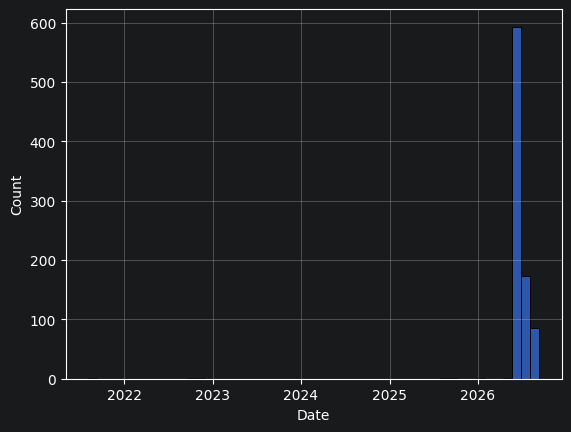

In [19]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [20]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-05-26,2026-05-27,2026-05-30,2026-06-03,2026-06-15,2026-07-01,2026-08-03,2026-08-28,2026-09-03


In [21]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,34,-127.96,"(-24.5, -9.8, -4.9, -0.98, 5.0, 9.0, 10.0, 20.0)",8
XYZ,17,-211.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,15,-89.64,"(-25.0, -10.0, -5.0, 0.36, 10.0, 20.0)",6
ORCL,14,-109.73,"(-10.0, -5.0, 0.27)",3
WFC,13,-55.64,"(-25.0, -10.0, -5.0, -1.0, 0.36, 10.0, 20.0)",7
META,13,-95.95,"(-10.0, -5.0, -1.0, 0.05)",4
AMZN,13,-231.00,"(-50.0, -25.0, -10.0, -1.0)",4
MCD,11,-109.80,"(-25.0, -10.0, -5.0, 0.2)",4
VGLT,11,-99.22,"(-25.0, -20.0, -10.0, -5.0, 0.06, 0.32, 0.4)",7


In [22]:
data['currency'].value_counts()

currency
USD    860
Name: count, dtype: int64

In [23]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    565
Stock Dividends              112
Deposits                      74
Stock Sell                    50
Bitcoin Buy                   24
Savings Internal Transfer     12
Bitcoin Sell                  10
P2P                            7
Account Notifications          3
Investing                      2
Withdrawal                     1
Name: count, dtype: int64

In [24]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Investing,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,,
total,24,10,2,565,112,50,763
BTC,24,10,0,0,0,0,34
XYZ,0,0,0,16,0,1,17
JPM,0,0,0,12,1,2,15
ORCL,0,0,0,13,1,0,14
AMZN,0,0,0,13,0,0,13
WFC,0,0,0,10,1,2,13
META,0,0,0,12,1,0,13
VGLT,0,0,0,8,3,0,11


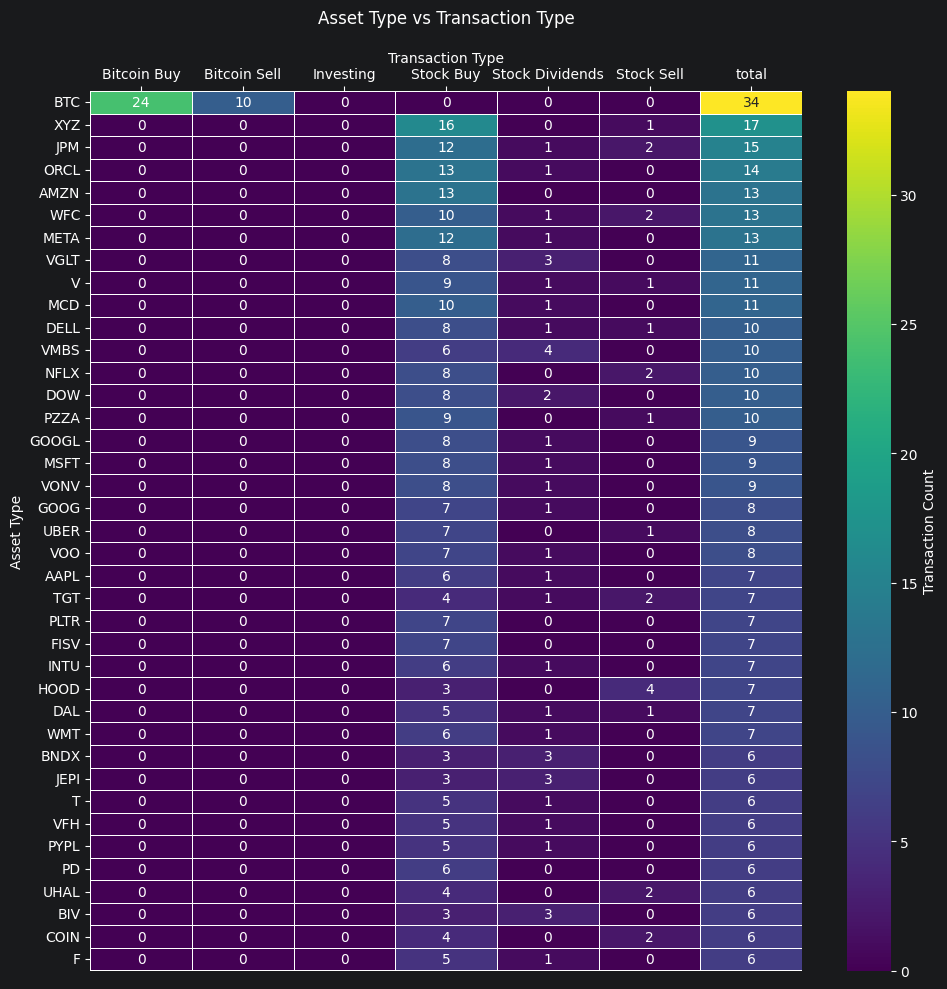

In [25]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [26]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc.head()

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
132,2026-07-16 13:31:06+00:00,8.82,9.0,63792.03,0.000141,-0.18,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00014108,NaN
156,2026-07-11 11:26:39+00:00,9.80,10.0,63645.54,0.000157,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015712,NaN
162,2026-07-10 14:02:46+00:00,9.80,10.0,63970.87,0.000156,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015632,NaN
183,2026-07-06 16:44:23+00:00,9.80,10.0,63170.74,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015830,NaN
195,2026-07-02 17:10:19+00:00,19.60,20.0,61217.07,0.000327,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032671,NaN


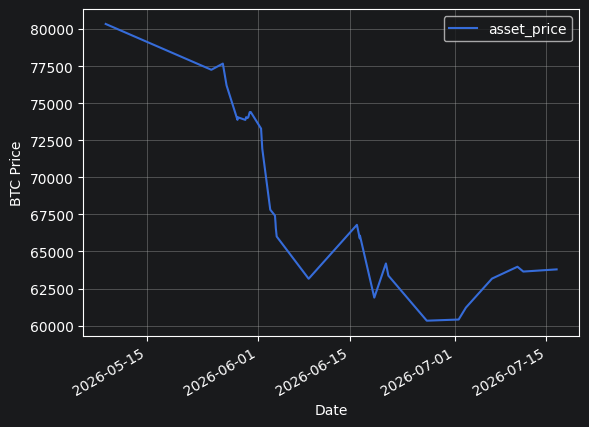

In [27]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [28]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     24
Bitcoin Sell    10
Name: count, dtype: int64

In [29]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-252.00
Bitcoin Sell,116.62


In [30]:
data_btc['net_amount'].sum()

np.float64(-135.38)

In [31]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003420
Bitcoin Sell    0.001889
Name: asset_amount, dtype: float64

In [32]:
data_btc['asset_amount'].sum()

np.float64(0.005308329999999999)

In [33]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00153091)

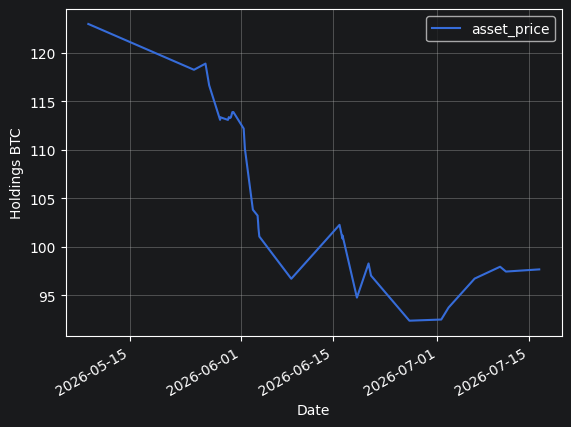

In [34]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [35]:
data_btc['asset_price'] * data_btc['asset_amount']

132     8.999780
156     9.999987
162     9.999926
183     9.999928
195    20.000229
223     9.800290
260     4.900090
315    10.000046
317     4.899747
326    19.999846
408     5.000156
409     4.999899
412     4.900240
448    19.999798
528     9.799846
555     9.800287
579     0.980144
676     9.800221
687     0.979969
704     9.799652
762     4.900136
764     9.799865
767     4.900112
768     9.799903
772     9.799965
776    24.500200
783    24.499951
787    24.500084
806     9.799731
810     9.800031
833    24.499991
850     9.799898
851     4.900356
852     9.799819
dtype: float64

In [36]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
19,2026-09-02 13:30:03+00:00,-10.0,-10.0,77.30,0.12936,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
103,2026-07-27 13:30:03+00:00,-10.0,-10.0,78.88,0.12677,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
111,2026-07-21 13:33:10+00:00,-10.0,-10.0,79.31,0.12608,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
178,2026-07-08 17:05:18+00:00,-10.0,-10.0,76.07,0.13145,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
259,2026-06-26 17:43:48+00:00,-10.0,-10.0,77.24,0.12946,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
288,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
370,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
415,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
463,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
539,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN


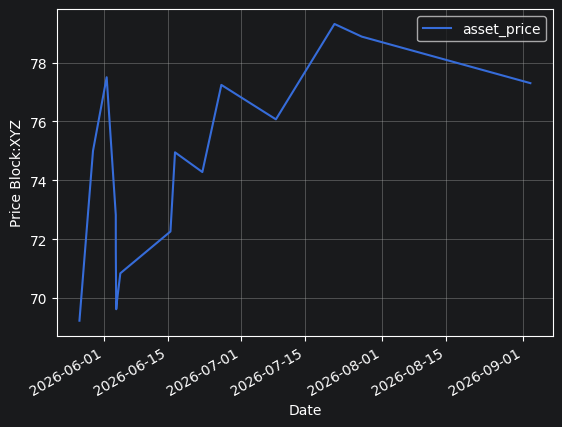

In [37]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [38]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     34
XYZ     17
JPM     15
ORCL    14
WFC     13
        ..
PENN     1
VGT      1
SNAP     1
SLAB     1
ZG       1
Name: amount, Length: 190, dtype: int64

In [39]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [40]:
data['asset_amount'].describe()

count    860.000000
mean       0.129226
std        0.306503
min        0.000000
25%        0.000067
50%        0.039315
75%        0.126925
max        4.509170
Name: asset_amount, dtype: float64

In [41]:
data[data['asset_type'] == 'ADP']

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
252,2026-07-01 04:00:00+00:00,0.15,0.15,NaN,0.00000,0.0,ADP,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.15 Dividend from Automatic Data Processing,NaN
325,2026-06-18 17:14:10+00:00,-10.00,-10.00,217.48,0.04598,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
589,2026-06-03 15:08:22+00:00,-10.00,-10.00,226.23,0.04420,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN
714,2026-06-01 13:30:28+00:00,-10.00,-10.00,223.99,0.04464,0.0,ADP,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Automatic Data Processing,NaN


In [42]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    [data['trans_type'].isin(stock_amount_direction.keys())]
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
    .sort_index()
)
asset_holding_time.sample(10, random_state=0xCAFE).sort_index()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 13:30:15+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,9.549584,0.000000,14.039852,0.000000,...,0.000000e+00,30.766264,9.686363,19.992722,0.0,93.073427,0.000000,9.953370,0.000000,0.000000
2026-06-03 13:48:39+00:00,20.147721,9.999493,9.010079,8.379889,10.098907,0.000000,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,31.527923,9.686363,19.992722,0.0,99.663815,0.000000,9.953370,0.000000,0.000000
2026-06-03 19:32:54+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,51.890247,18.724670,27.762524,0.0,131.892037,19.945984,9.953370,0.000000,0.000000
2026-06-03 19:38:51+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,0.000000,14.039852,0.000000,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-06-04 13:30:18+00:00,20.147721,9.999493,9.010079,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,63.030258,18.724670,27.762524,0.0,131.892037,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:09:55+00:00,28.691891,9.999493,0.000000,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,0.000000,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-06-18 17:13:02+00:00,28.691891,9.999493,0.000000,8.379889,19.320923,9.999577,20.893584,11.051107,14.039852,20.071824,...,0.000000e+00,85.406771,0.000000,27.762524,0.0,174.501547,30.191289,9.953370,9.999727,9.999925
2026-07-10 13:30:11+00:00,0.000000,9.999493,0.000000,8.379889,0.000000,9.999577,0.000000,0.000000,0.000000,30.069556,...,6.113515e+00,58.199610,0.000000,0.000000,0.0,196.334284,52.997013,19.954137,9.999727,9.999925
2026-07-27 13:30:17+00:00,0.000000,9.999493,0.000000,18.377823,0.000000,9.999577,0.000000,0.000000,0.000000,30.069556,...,-8.337775e-16,0.000000,0.000000,0.000000,0.0,210.903774,52.997013,19.954137,9.999727,9.999925


In [43]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3018.5339249999997)

In [44]:
asset_holding_time_last = asset_holding_time.iloc[-1].sort_values(ascending=False)
asset_holding_time_last.head()

asset_type
AMZN    241.595026
XYZ     220.903302
MCD     105.533327
JPM     104.538330
UBER     96.165081
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [45]:
asset_holding_time_last.tail()

asset_type
OXY     0.000000e+00
OWL     0.000000e+00
AAPL    0.000000e+00
WEN    -8.337775e-16
BTC              NaN
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [46]:
zero_assets = asset_holding_time_last[asset_holding_time_last == 0.0].sort_index().index
zero_assets

Index(['AAPL', 'ACN', 'ADP', 'ALKT', 'ALLY', 'AMAT', 'AMX', 'ASML', 'AVGO',
       'BBEU', 'BIV', 'BND', 'BNDX', 'BSV', 'C', 'CAT', 'CG', 'CLX', 'COKE',
       'CRM', 'CSCO', 'CVS', 'CXSE', 'DAL', 'DELL', 'DIS', 'DKS', 'DOW', 'EA',
       'EBAY', 'EMB', 'F', 'FIS', 'GAP', 'GIS', 'GM', 'GSLC', 'H', 'HPQ',
       'IBM', 'ILMN', 'INTU', 'JEPI', 'KO', 'KR', 'KWEB', 'LECO', 'LEVI', 'MA',
       'MS', 'MSFT', 'NOBL', 'NTAP', 'NVDA', 'ORCL', 'OWL', 'OXY', 'PNC',
       'POR', 'PPG', 'PSKY', 'QCOM', 'RUM', 'RUN', 'SBUX', 'T', 'TGT', 'TSM',
       'TXN', 'UPS', 'V', 'VBR', 'VCSH', 'VDC', 'VFH', 'VGLT', 'VGSH', 'VHT',
       'VMBS', 'VNQ', 'VONG', 'VRSN', 'VSS', 'VTEB', 'VZ', 'WFC', 'WMG', 'WMT',
       'XLB'],
      dtype='str', name='asset_type')

In [47]:
data[data['asset_type'].isin(zero_assets)][['asset_type', 'notes']].sort_values('asset_type')

,asset_type,notes
446,AAPL,$10 Purchase of Apple
296,AAPL,$10 Purchase of Apple
699,AAPL,$10 Purchase of Apple
241,AAPL,$10 Purchase of Apple
184,AAPL,$10 Purchase of Apple
...,...,...
232,WMT,$10 Purchase of Walmart
585,WMT,$10 Purchase of Walmart
177,WMT,$10 Purchase of Walmart
673,XLB,$10 Purchase of Materials Select Sector SPDR


In [48]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-31 13:30:06+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:13+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:16+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:17+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-09-02 13:30:03+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.073182,0.017557,0.006611,0.003313,0.003313


In [49]:
asset_price_rel.iloc[-1].describe()

count    1.890000e+02
mean     5.291005e-03
std      1.015541e-02
min     -2.762194e-19
25%      0.000000e+00
50%      3.312213e-03
75%      6.617206e-03
max      8.003721e-02
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [50]:
asset_price_rel_last = asset_price_rel.iloc[-1].sort_values(ascending=False)
asset_price_rel_last.head()

asset_type
AMZN    0.080037
XYZ     0.073182
MCD     0.034962
JPM     0.034632
UBER    0.031858
Name: 2026-09-02 13:30:03+00:00, dtype: float64

In [51]:
asset_price_rel_last.tail()

asset_type
OXY     0.000000e+00
OWL     0.000000e+00
AAPL    0.000000e+00
WEN    -2.762194e-19
BTC              NaN
Name: 2026-09-02 13:30:03+00:00, dtype: float64

<Axes: ylabel='Frequency'>

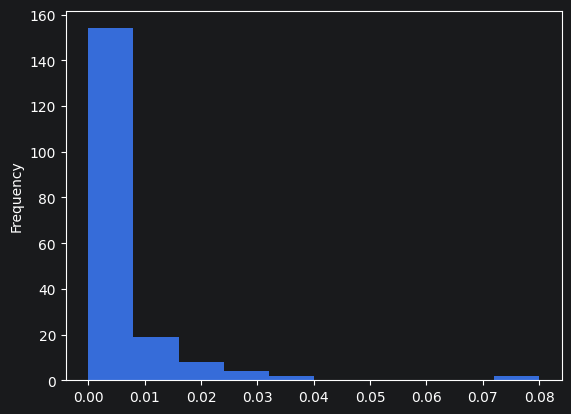

In [52]:
asset_price_rel_last.plot.hist()

In [53]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-31 13:30:06+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:13+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:16+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-08-31 13:30:17+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.069870,0.017557,0.006611,0.003313,0.003313
2026-09-02 13:30:03+00:00,0.0,0.003313,0.0,0.006088,0.0,0.003313,0.0,0.0,0.0,0.009962,...,-2.762194e-19,0.0,0.0,0.0,0.0,0.073182,0.017557,0.006611,0.003313,0.003313


In [54]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-08 16:33:33+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-10 13:30:15+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-28 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:39:17+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,543.37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:15:27+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:50:14+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,69.62,NaN,NaN,NaN,NaN
2026-06-22 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 16:52:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-08 16:33:33+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-07-10 13:30:15+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.342357,1.072471,0.921293,0.939144,1.0,1.098801,1.075766,0.995338,1.0,1.0
2026-08-28 13:30:21+00:00,1.017280,1.0,0.719207,0.838148,0.970936,1.0,1.020619,1.105111,1.404207,1.003791,...,1.195860,1.124661,0.921293,0.939144,1.0,1.139390,1.075766,0.995338,1.0,1.0
2026-06-03 19:39:17+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-07-01 13:30:23+00:00,0.969248,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.404207,1.003791,...,1.000000,1.071179,0.921293,0.976969,1.0,1.115701,1.005550,0.995338,1.0,1.0
2026-06-18 17:15:27+00:00,1.018386,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-03 15:50:14+00:00,1.021803,1.0,1.000000,1.000000,1.010000,1.0,0.954965,1.000000,1.000000,1.000000,...,1.000000,1.008655,1.000000,0.976969,1.0,1.005633,1.000000,1.000000,1.0,1.0
2026-06-22 13:30:01+00:00,1.018386,1.0,0.719207,1.000000,0.970936,1.0,0.954965,1.105111,1.000000,1.000000,...,1.000000,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0
2026-06-02 16:52:54+00:00,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

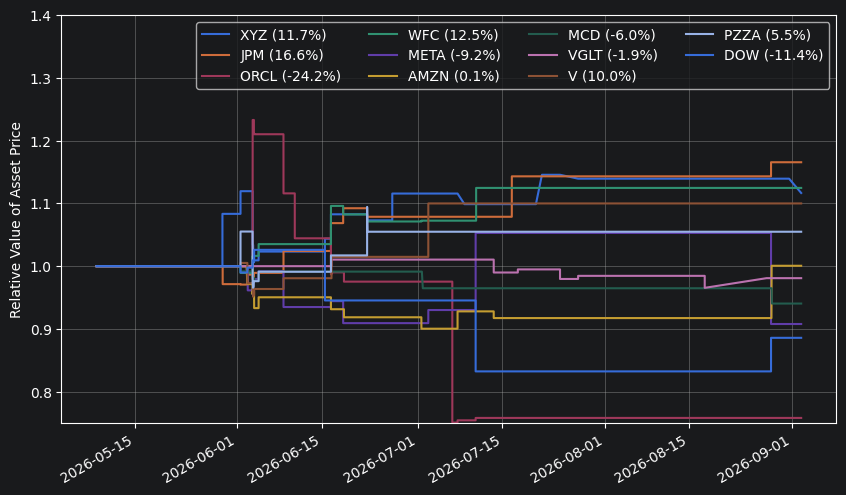

In [56]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(10, 6))
asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=4, loc='upper right')
plt.ylim(0.75, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [57]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-08-31 13:30:06+00:00    1.139390
2026-08-31 13:30:13+00:00    1.139390
2026-08-31 13:30:16+00:00    1.139390
2026-08-31 13:30:17+00:00    1.139390
2026-09-02 13:30:03+00:00    1.116568
Name: XYZ, Length: 517, dtype: float64

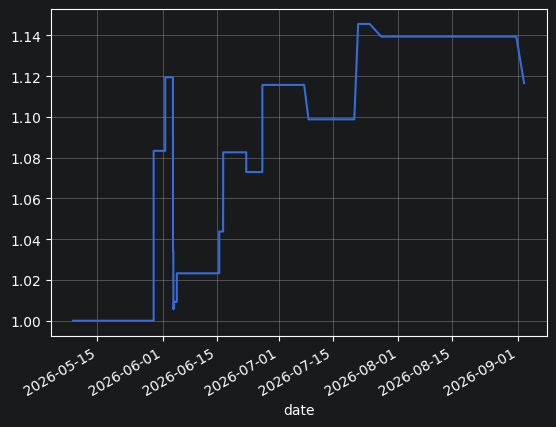

In [58]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [59]:
div_data = (
    data
    .sort_values('date', ascending=False)
    .assign(asset_price=lambda x: x['asset_price'].ffill())
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    [data['trans_type'] == 'Stock Dividends']
    .drop(columns=['fee', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

/var/folders/ll/02466vfd3qb7kfp5yfm5wx340000gn/T/ipykernel_35278/2296917298.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data


,date,amount,asset_price,asset_amount,asset_type,notes,stock_direction
0,2026-09-11,0.05,NaN,0.0,EBAY,$0.05 Dividend from eBay,NaN
1,2026-09-11,0.06,NaN,0.0,PPG,$0.06 Dividend from PPG,NaN
2,2026-09-11,0.95,NaN,0.0,DOW,$0.95 Dividend from Dow,NaN
3,2026-09-10,0.17,NaN,0.0,IBM,$0.17 Dividend from IBM,NaN
4,2026-09-10,0.01,NaN,0.0,AMAT,$0.01 Dividend from Applied Materials,NaN
...,...,...,...,...,...,...,...
410,2026-06-16,0.20,65883.50,0.0,MCD,$0.20 Dividend from McDonald's,NaN
428,2026-06-15,0.02,490.50,0.0,GOOG,$0.02 Dividend from Alphabet Inc. Class C,NaN
429,2026-06-15,0.02,490.50,0.0,GOOGL,$0.02 Dividend from Alphabet Inc. Class A,NaN
432,2026-06-12,0.05,490.50,0.0,DOW,$0.05 Dividend from Dow,NaN


In [60]:
div_data['amount'].sum()

np.float64(14.530000000000001)

In [61]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_price,asset_amount,asset_type,notes,stock_direction
2,2026-09-11,0.95,NaN,0.0,DOW,$0.95 Dividend from Dow,NaN
86,2026-08-03,0.48,712.39,0.0,T,$0.48 Dividend from AT&T,NaN
17,2026-09-03,0.40,NaN,0.0,VGLT,$0.40 Dividend from Vanguard Long-Treasury ETF,NaN
87,2026-08-03,0.38,712.39,0.0,VZ,$0.38 Dividend from Verizon Communications,NaN
91,2026-07-31,0.36,712.39,0.0,JPM,$0.36 Dividend from JPMorgan Chase,NaN
...,...,...,...,...,...,...,...
279,2026-06-23,0.01,6.28,0.0,VONG,$0.01 Dividend from Vanguard Russell 1000 Grow...,NaN
254,2026-06-30,0.01,353.85,0.0,AVGO,$0.01 Dividend from Broadcom,NaN
6,2026-09-10,0.01,NaN,0.0,H,$0.01 Dividend from Hyatt Hotels Corporation,NaN
4,2026-09-10,0.01,NaN,0.0,AMAT,$0.01 Dividend from Applied Materials,NaN


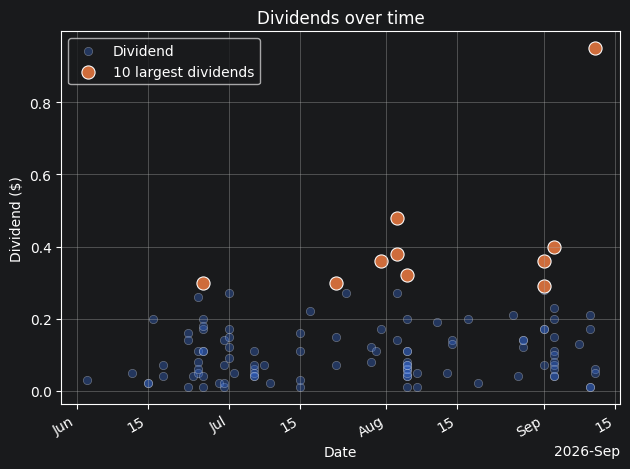

In [62]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [63]:
(div_data
 .groupby('asset_type')
 .agg(
    count=('amount', 'size'),
    total=('amount', 'sum'),
    mean=('amount', lambda x: x.mean().round(3)),
    # asset_price=('asset_price', lambda x: x.mean().round(3)),
    start=('date', 'min'),
    end=('date', 'max'),
    notes=('notes', lambda x: x.sort_values().tolist()[0]),
)
 .sort_values(['count', 'total', 'mean'], ascending=False)
 )

,count,total,mean,start,end,notes
asset_type,,,,,,
VMBS,4,0.40,0.100,2026-06-03,2026-09-03,$0.03 Dividend from Vanguard Mortgage-Backed S...
VGLT,3,0.78,0.260,2026-07-06,2026-09-03,$0.06 Dividend from Vanguard Long-Treasury ETF
JEPI,3,0.47,0.157,2026-07-06,2026-09-03,$0.07 Dividend from JPMorgan Equity Premium In...
BIV,3,0.26,0.087,2026-07-06,2026-09-03,$0.04 Dividend from Vanguard Intermediate Term...
BNDX,3,0.18,0.060,2026-07-06,2026-09-03,$0.05 Dividend from Vanguard Total Internation...
...,...,...,...,...,...,...
COKE,1,0.01,0.010,2026-08-07,2026-08-07,$0.01 Dividend from Coca-Cola Consolidated
H,1,0.01,0.010,2026-09-10,2026-09-10,$0.01 Dividend from Hyatt Hotels Corporation
NVDA,1,0.01,0.010,2026-06-26,2026-06-26,$0.01 Dividend from NVIDIA


In [64]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
628,2026-06-03 13:30:13+00:00,-10.00,48.13,$10 Purchase of Vanguard Total International B...,BNDX
85,2026-08-05 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Intermediate Term...,BIV
332,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
194,2026-07-06 04:00:00+00:00,0.11,NaN,$0.11 Dividend from Vanguard Mortgage-Backed S...,VMBS
65,2026-08-13 13:30:04+00:00,-9.99,712.39,$9.99 Purchase of Vanguard S&P 500 ETF,VOO
634,2026-06-03 13:30:11+00:00,-10.00,390.01,$10 Purchase of Vanguard Consumer Discretionar...,VCR
399,2026-06-16 13:30:05+00:00,-5.00,98.42,$5 Purchase of Vanguard Real Estate ETF,VNQ
234,2026-07-01 14:17:44+00:00,-10.00,686.18,$10 Purchase of Vanguard S&P 500 ETF,VOO
646,2026-06-03 13:30:09+00:00,-10.00,220.70,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
74,2026-08-05 04:00:00+00:00,0.04,NaN,$0.04 Dividend from Vanguard Short-Term Corpor...,VCSH


In [65]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VGLT    11
VMBS    10
VONV     9
VOO      8
BNDX     6
BIV      6
VFH      6
VTEB     5
BND      5
VDE      5
BSV      4
VGSH     4
VCR      4
VNQ      4
VHT      4
VSS      4
VCSH     3
VBR      3
VDC      3
VONG     3
VGT      1
Name: count, dtype: int64

In [66]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
628,2026-06-03 13:30:13+00:00,-10.00,48.13,BNDX,Vanguard Total International Bond ETF
85,2026-08-05 04:00:00+00:00,0.11,NaN,BIV,NaN
332,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
194,2026-07-06 04:00:00+00:00,0.11,NaN,VMBS,NaN
65,2026-08-13 13:30:04+00:00,-9.99,712.39,VOO,Vanguard S&P 500 ETF
634,2026-06-03 13:30:11+00:00,-10.00,390.01,VCR,Vanguard Consumer Discretionary ETF
399,2026-06-16 13:30:05+00:00,-5.00,98.42,VNQ,Vanguard Real Estate ETF
234,2026-07-01 14:17:44+00:00,-10.00,686.18,VOO,Vanguard S&P 500 ETF
646,2026-06-03 13:30:09+00:00,-10.00,220.70,VDC,Vanguard Consumer Staples Index Fund ETF
74,2026-08-05 04:00:00+00:00,0.04,NaN,VCSH,NaN


In [67]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VGLT        Vanguard Long-Treasury ETF                     8
VONV        Vanguard Russell 1000 Value ETF                8
VOO         Vanguard S&P 500 ETF                           7
VMBS        Vanguard Mortgage-Backed Securities ETF        6
VFH         Vanguard Financials ETF                        5
VDE         Energy ETF Vanguard                            4
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
VHT         Vanguard Health Care ETF                       3
BND         Vanguard Total Bond Market ETF                 3
BIV         Vanguard Intermediate Term Bond ETF            3
VCR         Vanguard Consumer Discretionary ETF            3
BNDX        Vanguard Total International Bond ETF          3
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGSH        Vanguard Short-Term Treasury ETF               2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 

In [68]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VGLT,VMBS,VONV,VOO,BNDX,BIV,VFH,VTEB,BND,VDE,...,VGSH,VCR,VNQ,VHT,VSS,VCSH,VBR,VDC,VONG,VGT
date,,,,,,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-17 13:30:14+00:00,NaN,46.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:22+00:00,NaN,NaN,NaN,NaN,47.68,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-17 13:30:23+00:00,52.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
vanguard_trans_count

asset_type
VGLT    11
VMBS    10
VONV     9
VOO      8
BNDX     6
BIV      6
VFH      6
VTEB     5
BND      5
VDE      5
BSV      4
VGSH     4
VCR      4
VNQ      4
VHT      4
VSS      4
VCSH     3
VBR      3
VDC      3
VONG     3
VGT      1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

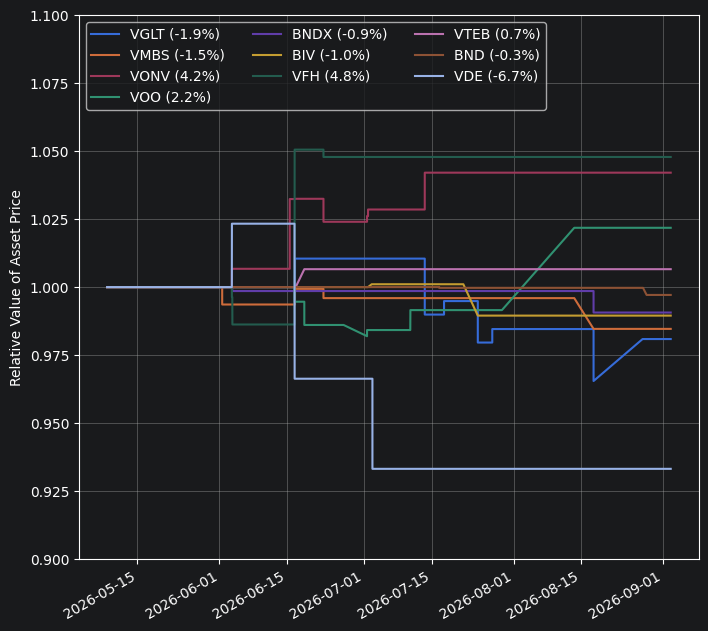

In [70]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.head(10).index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.ylim(0.9, 1.1)
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [71]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
30,2026-08-28 22:38:29+00:00,10.0,Visa debit 3333,COMPLETE,Add Cash
48,2026-08-28 11:42:14+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
54,2026-08-27 17:23:15+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
104,2026-07-26 14:27:29+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
119,2026-07-17 09:46:47+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
844,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
845,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
846,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
847,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [72]:
data_deposits['net_amount'].sum()

np.float64(6545.96)

In [73]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,74.0,88.458919,47.826235,1.0,62.5,100.0,100.0,200.0


In [74]:
data_deposits['net_amount'].cumsum()

30       10.00
48      110.00
54      210.00
104     310.00
119     410.00
        ...   
844    6440.96
845    6450.96
846    6500.96
847    6520.96
848    6545.96
Name: net_amount, Length: 74, dtype: float64

In [75]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
848,2026-05-26 19:39:34+00:00,25.00
847,2026-05-26 21:58:29+00:00,45.00
846,2026-05-27 00:43:01+00:00,95.00
845,2026-05-27 00:56:05+00:00,105.00
844,2026-05-27 00:56:27+00:00,205.00
...,...,...
119,2026-07-17 09:46:47+00:00,6235.96
104,2026-07-26 14:27:29+00:00,6335.96
54,2026-08-27 17:23:15+00:00,6435.96
48,2026-08-28 11:42:14+00:00,6535.96


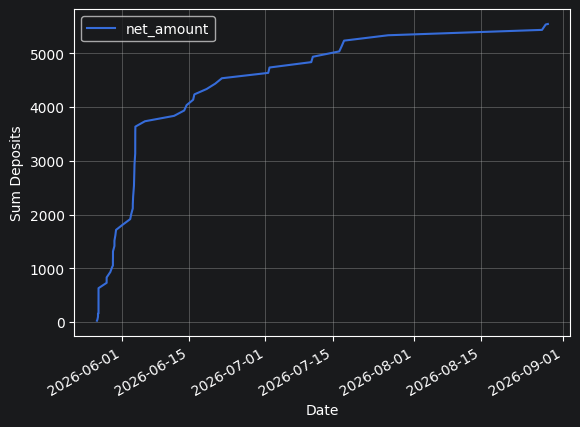

In [76]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [77]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.0
2026-05-26 21:58:29+00:00,0.0,20.0
2026-05-27 00:43:01+00:00,0.0,50.0
2026-05-27 00:56:05+00:00,0.0,10.0
2026-05-27 00:57:28+00:00,0.0,50.0
...,...,...
2026-07-17 09:46:47+00:00,100.0,0.0
2026-07-26 14:27:29+00:00,100.0,0.0
2026-08-27 17:23:15+00:00,100.0,0.0


In [78]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    5210.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64